# 01 · Environmental Claim Detector (ClimateBERT) — train, evaluate, publish

GreenTruth's text side: fine-tune a small climate transformer to tell an
environmental **claim** from a non-claim, then publish it to the Hugging Face Hub.

**Data source**
```
Dataset:   climatebert/environmental_claims  (2,647 expert-annotated sentences)
Paper:     Stammbach et al., ACL 2023 — https://arxiv.org/abs/2209.00507
Dataset:   https://huggingface.co/datasets/climatebert/environmental_claims
Base:      https://huggingface.co/climatebert/distilroberta-base-climate-f
License:   CC BY-NC-SA 4.0 (non-commercial — the trained model inherits it)
Publish to: https://huggingface.co/Rahilgh/greentruth-claim-detector
```

Real dataset, real metrics from your run. The paper reports macro-F1 ≈ 85%; expect
that range, don't assert it. Set the runtime to **GPU**.

### 1 · Install and import

In [1]:
!pip install -q transformers datasets scikit-learn huggingface_hub matplotlib

In [2]:
import numpy as np, torch, transformers
from datasets import load_dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from sklearn.metrics import (precision_recall_fscore_support, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
print("transformers", transformers.__version__, "| GPU:", torch.cuda.is_available())

transformers 5.16.1 | GPU: True


### 2 · Load the dataset (text = sentence, label 1 = environmental claim)

In [3]:
ds = load_dataset("climatebert/environmental_claims")
print(ds)
if "test" not in ds:
    t = ds["train"].train_test_split(test_size=0.2, seed=42)
    ds = DatasetDict({"train": t["train"], "test": t["test"]})
if "validation" not in ds:
    t = ds["train"].train_test_split(test_size=0.1, seed=42)
    ds = DatasetDict({"train": t["train"], "validation": t["test"], "test": ds["test"]})
for s in ds:
    y = ds[s]["label"]; pos = sum(y)
    print(f"{s:12s} n={len(y):5d} claims={pos:4d} non={len(y)-pos:4d}")

README.md:   0%|          | 0.00/4.25k [00:00<?, ?B/s]

data/train-00000-of-00001-98aa5228a06a17(…): reconstructing file:   0%|          |  0.00B /  215kB            

data/train-00000-of-00001-98aa5228a06a17(…): downloading bytes:           |  0.00B            

data/validation-00000-of-00001-2553e47d4(…): reconstructing file:   0%|          |  0.00B / 28.9kB            

data/validation-00000-of-00001-2553e47d4(…): downloading bytes:           |  0.00B            

...

data/test-00000-of-00001-79fd931297fff76(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2117 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/265 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/265 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 2117
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 265
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 265
    })
})
train        n= 2117 claims= 532 non=1585
validation   n=  265 claims=  66 non= 199
test         n=  265 claims=  67 non= 198


### 3 · Tokenize

In [4]:
MODEL_NAME = "climatebert/distilroberta-base-climate-f"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
def prep(b): return tokenizer(b["text"], truncation=True, max_length=256)
enc = ds.map(prep, batched=True)
collator = DataCollatorWithPadding(tokenizer)

config.json:   0%|          | 0.00/752 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.46k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.15M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/4.98k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Map:   0%|          | 0/2117 [00:00<?, ? examples/s]

Map:   0%|          | 0/265 [00:00<?, ? examples/s]

Map:   0%|          | 0/265 [00:00<?, ? examples/s]

### 4 · Model, metrics, training arguments

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    id2label={0: "not_claim", 1: "environmental_claim"},
    label2id={"not_claim": 0, "environmental_claim": 1})

def compute_metrics(p):
    preds = np.argmax(p.predictions if hasattr(p, 'predictions') else p[0], axis=-1)
    labels = p.label_ids if hasattr(p, 'label_ids') else p[1]
    pr, rc, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"accuracy": accuracy_score(labels, preds), "precision": pr, "recall": rc, "f1": f1}

OUTPUT_DIR = "greentruth-claim-detector"
def make_args(**kw):
    try:    return TrainingArguments(eval_strategy="epoch", save_strategy="epoch", **kw)
    except TypeError:
        return TrainingArguments(evaluation_strategy="epoch", save_strategy="epoch", **kw)
args = make_args(output_dir=OUTPUT_DIR, learning_rate=2e-5,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    num_train_epochs=3, weight_decay=0.01, load_best_model_at_end=True,
    metric_for_best_model="f1", logging_steps=20, report_to="none")

model.safetensors: reconstructing file:   0%|          |  0.00B /  329MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: climatebert/distilroberta-base-climate-f
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 5 · Train

In [7]:
trainer = Trainer(model=model, args=args,
    train_dataset=enc["train"], eval_dataset=enc["validation"],
    data_collator=collator, compute_metrics=compute_metrics)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.259610,0.235048,0.898113,0.853734,0.906845,0.873963
2,0.143656,0.251107,0.913208,0.872635,0.916895,0.890820
3,0.110096,0.266856,0.901887,0.857998,0.914421,0.879123


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=399, training_loss=0.20957245474172415, metrics={'train_runtime': 85.8918, 'train_samples_per_second': 73.942, 'train_steps_per_second': 4.645, 'total_flos': 89180571440496.0, 'train_loss': 0.20957245474172415, 'epoch': 3.0})

### 6 · Evaluate on the held-out test split

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.110096,0.273520,3,0.905660,0.865899,0.902307,0.881326


{'eval_loss': 0.2735, 'eval_accuracy': 0.9057, 'eval_precision': 0.8659, 'eval_recall': 0.9023, 'eval_f1': 0.8813}


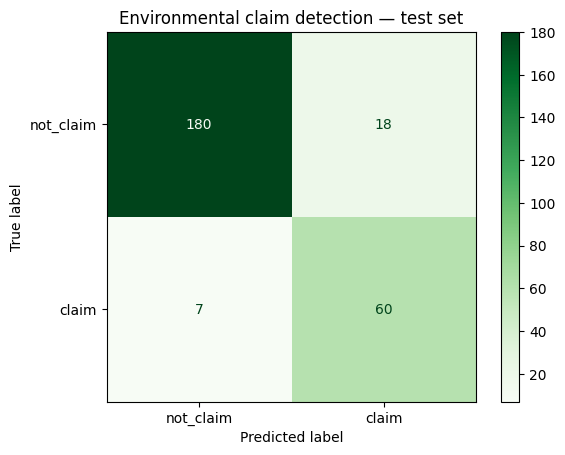

In [8]:
m = trainer.evaluate(enc["test"])
print({k: round(v, 4) for k, v in m.items() if k.startswith("eval_")})
pred = trainer.predict(enc["test"])
y_true, y_pred = pred.label_ids, np.argmax(pred.predictions, axis=-1)
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
    display_labels=["not_claim", "claim"]).plot(cmap="Greens")
plt.title("Environmental claim detection — test set"); plt.show()

These are the metrics **your run** produced. The source paper reports macro-F1 ≈ 85% for comparable models; a similar range is expected. Don't edit the numbers.

### 7 · Save locally

In [9]:
trainer.save_model(OUTPUT_DIR); tokenizer.save_pretrained(OUTPUT_DIR)
print("saved to", OUTPUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved to greentruth-claim-detector


### 8 · Publish to the Hugging Face Hub

Log in with a **write** token from https://huggingface.co/settings/tokens. Never
paste a token into a saved cell. Your account is `Rahilgh`.

In [10]:
from huggingface_hub import notebook_login
notebook_login()

In [11]:
HF_USERNAME = "Rahilgh"
REPO_ID = f"{HF_USERNAME}/greentruth-claim-detector"

MODEL_CARD = f"""---
license: cc-by-nc-sa-4.0
language: en
base_model: climatebert/distilroberta-base-climate-f
datasets: [climatebert/environmental_claims]
tags: [text-classification, climate, esg, greenwashing]
---

# GreenTruth Claim Detector

Binary classifier flagging whether a sentence is an environmental claim. Text stage
of GreenTruth, which checks environmental claims against Earth-observation evidence.

## Intended use
Find checkable environmental claims in corporate disclosures, before evidence-grounded
verification. Detecting a claim is not judging it.

## Training
Fine-tuned climatebert/distilroberta-base-climate-f on the environmental_claims dataset
(Stammbach et al., ACL 2023): 3 epochs, lr 2e-5, batch 16, max length 256.

## Evaluation
See the notebook run for test precision/recall/macro-F1/accuracy. The paper reports
macro-F1 around 85% for comparable models.

## Limitations & ethics
English, listed-company text; domain shift is likely. Detects a claim, not its truth.
Inherits CC BY-NC-SA 4.0 (non-commercial). Do not use to label a company deceptive.

## Dataset
https://huggingface.co/datasets/climatebert/environmental_claims
"""
with open(f"{OUTPUT_DIR}/README.md", "w") as f:
    f.write(MODEL_CARD)

model.push_to_hub(REPO_ID); tokenizer.push_to_hub(REPO_ID)
from huggingface_hub import upload_file
upload_file(path_or_fileobj=f"{OUTPUT_DIR}/README.md", path_in_repo="README.md", repo_id=REPO_ID)
print("pushed to https://huggingface.co/" + REPO_ID)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...qrt5df4/model.safetensors:   0%|          |  551kB /  329MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

pushed to https://huggingface.co/Rahilgh/greentruth-claim-detector


### 9 · Reload from the Hub and run inference

In [12]:
from transformers import pipeline
clf = pipeline("text-classification", model=REPO_ID)   # or OUTPUT_DIR for the local copy
for s in ["We reduced routine flaring by 30% by 2023 from 2019 levels.",
          "The board met four times during the reporting period.",
          "We are committed to reaching net zero by 2050.",
          "Our teams volunteered thousands of hours in the community."]:
    r = clf(s)[0]; print(f"[{r['label']:18s} {r['score']:.2f}]  {s}")

config.json:   0%|          | 0.00/959 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  329MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/388 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.60M [00:00<?, ?B/s]

[environmental_claim 0.94]  We reduced routine flaring by 30% by 2023 from 2019 levels.
[not_claim          1.00]  The board met four times during the reporting period.
[environmental_claim 0.98]  We are committed to reaching net zero by 2050.
[not_claim          0.99]  Our teams volunteered thousands of hours in the community.


### 10 · How GreenTruth uses this model

The app calls this detector in place of the rule baseline, keeping the rule detector as an offline fallback. Detection is stage one; the evidence stages decide whether a claim holds up.